# **Proyecto FCDIA: Análisis de Matrimonios y Divorcios 2020** #
## Este notebook organiza el flujo en: ##
1. Limpieza y preparación (EDA)
2. Generación de variables
3. Inspección y análisis de gráficos
4. Visualización y conclusiones
5. Clustering
6. Visualización y conclusiones

## **Limpieza y preparación (EDA)** ##

*//Importamos requerimientos para poder leer el dataset*

In [51]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

*//Importamos el dataset y hacemos una vista previa*

In [52]:
df = pd.read_csv(r'/workspaces/Analisis-Matrimonios-y-Divorcios-2020---Proyecto-FCDIA-/ProeyctoFCDIA/EDV_2020.csv',sep = ';')
df

,prov_insc,cant_insc,parr_insc,anio_insc,mes_insc,dia_insc,fecha_insc,anio_div,mes_div,dia_div,...,fecha_nac2,edad_2,hijos_2,p_etnica2,niv_inst2,sabe_leer2,prov_hab2,cant_hab2,parr_hab2,area_2
0,17,1701,170112,2020,6,30,6/30/2020,2019,12,16,...,,999,0,9,99,9,17,1701,170112,1
1,9,901,90110,2020,1,3,1/3/2020,2019,12,16,...,,999,0,6,6,1,9,901,90110,1
2,2,201,20101,2020,9,24,9/24/2020,2020,6,16,...,,999,99,1,6,1,2,201,20159,2
3,7,701,70102,2020,3,13,3/13/2020,2020,3,11,...,9/19/1972,47,0,6,5,1,88,8800,880000,1
4,7,701,70102,2020,8,26,8/26/2020,2020,7,31,...,6/11/1984,36,0,6,5,1,88,8800,880000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,12,1205,120502,2020,3,5,3/5/2020,2019,10,21,...,10/1/1990,29,1,6,5,1,5,503,50351,2
14564,12,1205,120502,2020,3,3,3/3/2020,2020,1,29,...,8/11/1978,41,0,6,6,1,9,901,90112,1
14565,12,1205,120502,2020,2,28,2/28/2020,2020,2,27,...,12/20/1951,68,0,6,3,1,12,1205,120509,1
14566,12,1205,120502,2020,2,20,2/20/2020,2019,12,20,...,8/24/1966,53,1,6,6,1,12,1205,120502,1


*//Nos damos cuenta que hay valores nulos representados por 9,99 y 999; procedemos con la eliminación de estos*

In [53]:
def limpiar_sentinela(df, columnas, valor):
    df[columnas] = df[columnas].replace(valor, pd.NA)

# Diccionario: valor centinela -> columnas
sentinelas = {
    99: [
        'niv_inst2','hijos_2','dia_nac2','mes_nac2',
        'niv_inst1','hijos_1','dia_nac1','cau_div','mes_nac1'
    ],
    9:  ['mcap_bie','nac_1','nac_2','sabe_leer1','sabe_leer2'],
    999: ['edad_1','edad_2'],
    9999: ['anio_nac1','anio_nac2']
}

# Aplicar limpieza
for valor, columnas in sentinelas.items():
    limpiar_sentinela(df, columnas, valor)

# Limpieza de columnas de fecha
columnas_fechas = [
    'fecha_insc','fecha_nac2','fecha_nac1','fecha_div','fecha_mat'
]
df[columnas_fechas] = df[columnas_fechas].replace(' ', pd.NA)

df = df.dropna().reset_index(drop=True)

*//Vemos los cambios en el dataset, esta vez sin nulos pero con menos información*

In [54]:
df

,prov_insc,cant_insc,parr_insc,anio_insc,mes_insc,dia_insc,fecha_insc,anio_div,mes_div,dia_div,...,fecha_nac2,edad_2,hijos_2,p_etnica2,niv_inst2,sabe_leer2,prov_hab2,cant_hab2,parr_hab2,area_2
0,9,901,90112,2020,7,30,7/30/2020,2020,6,30,...,5/7/1955,65,0,6,7,1,9,901,90114,1
1,17,1701,170126,2020,1,21,1/21/2020,2019,9,2,...,4/24/1975,44,1,7,7,1,88,8800,880000,1
2,9,901,90110,2020,9,22,9/22/2020,2018,8,19,...,1/3/1968,52,6,6,6,1,9,901,90112,1
3,9,901,90110,2020,2,13,2/13/2020,2020,2,13,...,11/23/1972,47,6,7,6,1,9,901,90114,1
4,17,1707,170750,2020,10,23,10/23/2020,2016,7,7,...,12/4/1967,52,8,6,3,1,17,1707,170750,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12320,12,1205,120502,2020,11,30,11/30/2020,2020,10,21,...,10/8/1983,37,2,6,8,1,9,901,90112,1
12321,12,1205,120502,2020,3,3,3/3/2020,2020,1,29,...,8/11/1978,41,0,6,6,1,9,901,90112,1
12322,12,1205,120502,2020,2,28,2/28/2020,2020,2,27,...,12/20/1951,68,0,6,3,1,12,1205,120509,1
12323,12,1205,120502,2020,2,20,2/20/2020,2019,12,20,...,8/24/1966,53,1,6,6,1,12,1205,120502,1


*//Inspección de columnas*

In [55]:
df.columns

Index(['prov_insc', 'cant_insc', 'parr_insc', 'anio_insc', 'mes_insc',
       'dia_insc', 'fecha_insc', 'anio_div', 'mes_div', 'dia_div', 'fecha_div',
       'anio_mat', 'mes_mat', 'dia_mat', 'fecha_mat', 'mcap_bie', 'dur_mat',
       'cau_div', 'nac_1', 'cod_pais1', 'sexo_1', 'anio_nac1', 'mes_nac1',
       'dia_nac1', 'fecha_nac1', 'edad_1', 'hijos_1', 'p_etnica1', 'niv_inst1',
       'sabe_leer1', 'prov_hab1', 'cant_hab1', 'parr_hab1', 'area_1', 'nac_2',
       'cod_pais2', 'sexo_2', 'anio_nac2', 'mes_nac2', 'dia_nac2',
       'fecha_nac2', 'edad_2', 'hijos_2', 'p_etnica2', 'niv_inst2',
       'sabe_leer2', 'prov_hab2', 'cant_hab2', 'parr_hab2', 'area_2'],
      dtype='str')

*//Creación de variable* **dia_sem_mat: el día de la semana donde ocurrió el matrimnio**

In [56]:
# Convertir a numérico
cols_fecha = ['dia_mat', 'mes_mat', 'anio_mat']
df[cols_fecha] = df[cols_fecha].apply(pd.to_numeric, errors='coerce')

# Crear fecha de matrimonio
df['fecha_mat'] = pd.to_datetime(
    df[['anio_mat', 'mes_mat', 'dia_mat']]
        .rename(columns={
            'anio_mat': 'year',
            'mes_mat': 'month',
            'dia_mat': 'day'
        }),
    errors='coerce'
)

# Día de la semana en español
dia_semana_map = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}
df['dia_sem_mat'] = df['fecha_mat'].dt.weekday.map(dia_semana_map)

*//Inspección selectiva por día de la fecha de matrimonio*

In [57]:
dfGroup01 = df.groupby(['dia_sem_mat'])
dfGroup01['dur_mat'].describe()

,count,mean,std,min,25%,50%,75%,max
dia_sem_mat,,,,,,,,
Domingo,241.0,21.601660,12.380724,0.0,13.0,19.0,30.0,60.0
Jueves,2138.0,14.315716,10.338625,0.0,6.0,12.0,21.0,64.0
Lunes,1275.0,15.603137,10.753963,0.0,7.0,13.0,23.0,57.0
Martes,1290.0,14.948062,10.776361,0.0,6.0,12.0,22.0,55.0
Miércoles,1749.0,15.432247,11.271743,0.0,6.0,13.0,23.0,57.0
Sábado,1143.0,17.511811,11.043521,0.0,9.0,16.0,24.0,55.0
Viernes,4489.0,13.889508,9.700750,0.0,6.0,12.0,20.0,58.0


*//¿Existe alguna correlación entre el día de la semana elegido para la boda y la longevidad del matrimonio?*

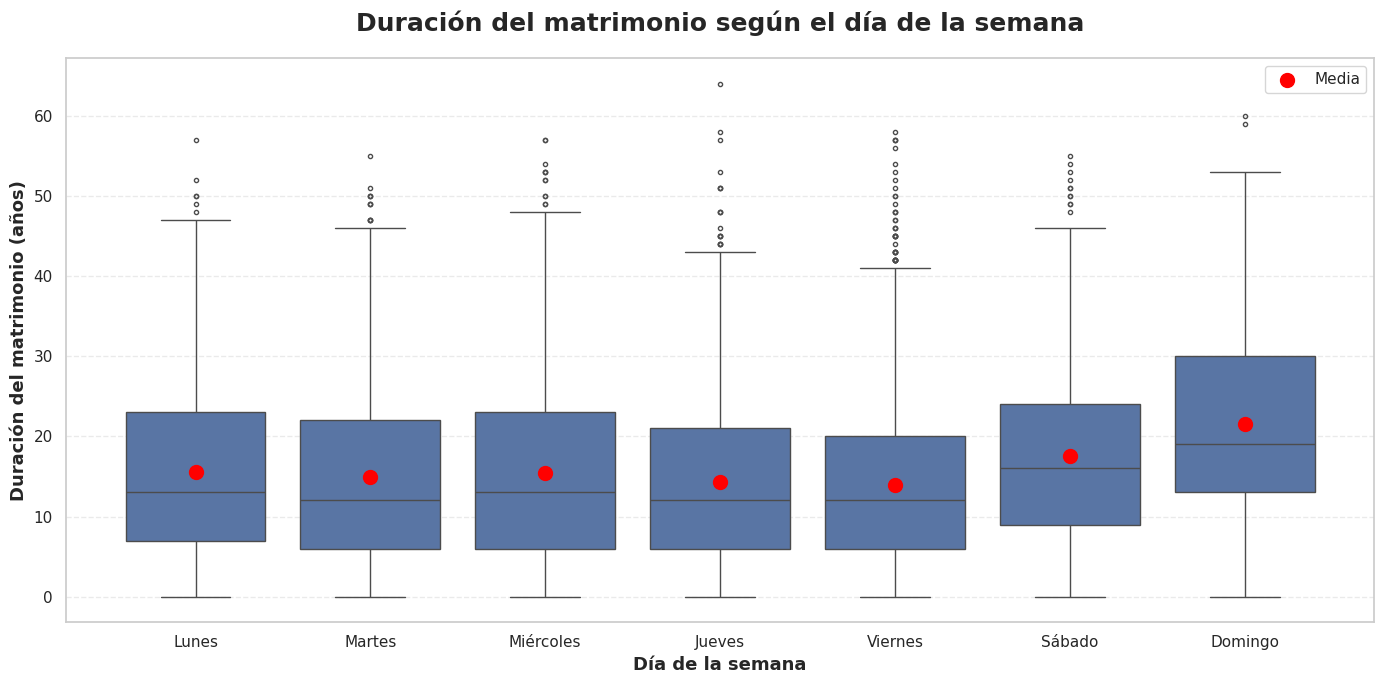

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# ORDEN DE LOS DÍAS
# ==========================================
orden_dias = [
    'Lunes', 'Martes', 'Miércoles',
    'Jueves', 'Viernes', 'Sábado', 'Domingo'
]

# ==========================================
# ESTILO GENERAL
# ==========================================
sns.set_theme(
    style='whitegrid',
    palette='deep'
)

# ==========================================
# CREAR FIGURA
# ==========================================
plt.figure(figsize=(14, 7))

# ==========================================
# BOXPLOT
# ==========================================
ax = sns.boxplot(
    data=df,
    x='dia_sem_mat',
    y='dur_mat',
    order=orden_dias,
    showfliers=True,
    fliersize=3
)

# ==========================================
# MEDIA
# ==========================================
medias = (
    df.groupby('dia_sem_mat')['dur_mat']
      .mean()
      .reindex(orden_dias)
)

ax.scatter(
    x=range(len(orden_dias)),
    y=medias,
    color='red',
    s=100,
    zorder=5,
    label='Media'
)

# ==========================================
# ETIQUETAS
# ==========================================
plt.xlabel(
    'Día de la semana',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Duración del matrimonio (años)',
    fontsize=13,
    fontweight='bold'
)

plt.title(
    'Duración del matrimonio según el día de la semana',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# ==========================================
# GRID
# ==========================================
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# ==========================================
# TICKS
# ==========================================
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# ==========================================
# LEYENDA
# ==========================================
plt.legend(
    fontsize=11,
    frameon=True
)

# ==========================================
# AJUSTE FINAL
# ==========================================
plt.tight_layout()

plt.show()

*//Grafico de barras para representar cantidad o conteo*

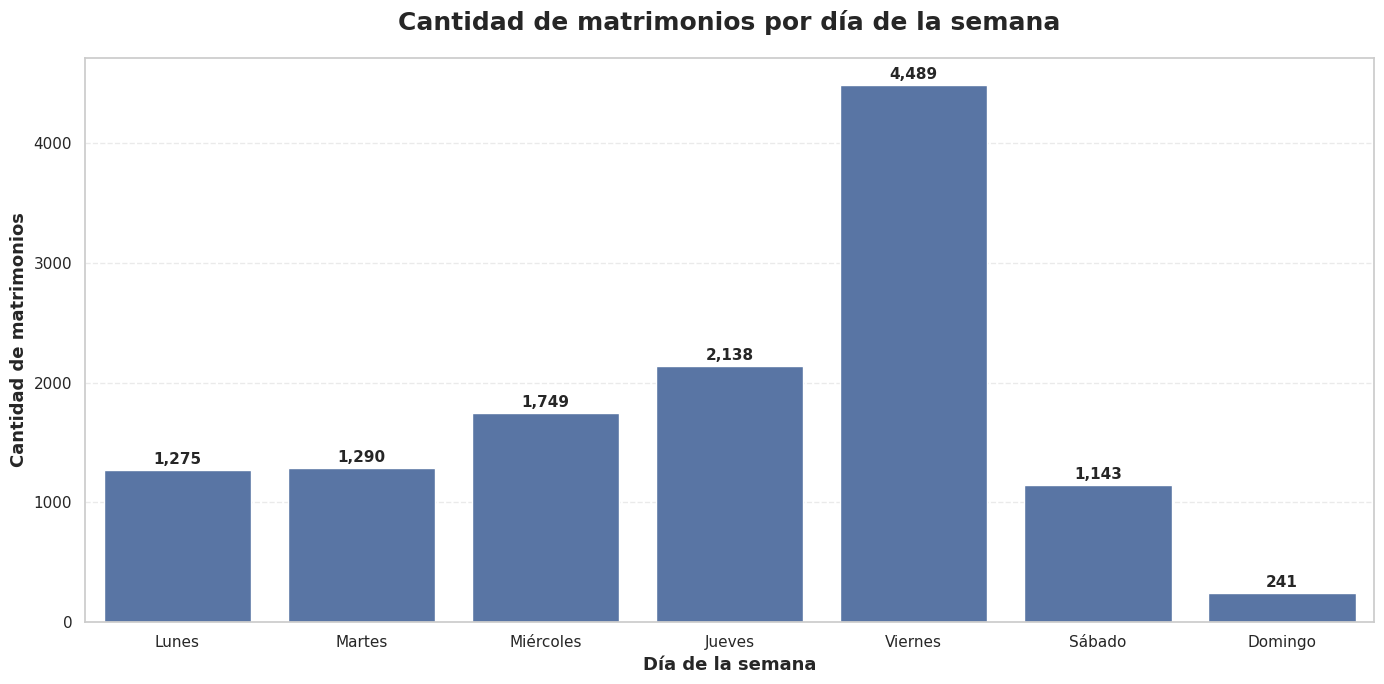

In [59]:
# ==========================================
# CONTAR MATRIMONIOS POR DÍA
# ==========================================
conteos = (
    df['dia_sem_mat']
      .value_counts()
      .reindex(orden_dias)
)

# ==========================================
# FIGURA
# ==========================================
plt.figure(figsize=(14, 7))

# ==========================================
# BARPLOT
# ==========================================
ax = sns.barplot(
    x=conteos.index,
    y=conteos.values
)

# ==========================================
# AGREGAR VALORES ENCIMA
# ==========================================
for i, valor in enumerate(conteos.values):

    ax.text(
        i,
        valor + 50,
        f'{valor:,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# ==========================================
# ETIQUETAS
# ==========================================
plt.xlabel(
    'Día de la semana',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Cantidad de matrimonios',
    fontsize=13,
    fontweight='bold'
)

plt.title(
    'Cantidad de matrimonios por día de la semana',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# ==========================================
# GRID
# ==========================================
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# ==========================================
# AJUSTE FINAL
# ==========================================
plt.tight_layout()

plt.show()

*//Cómo Viernes tiene una cantidad exagerada frente a otros días como Domingo o Sábado se usa un Violinplot*

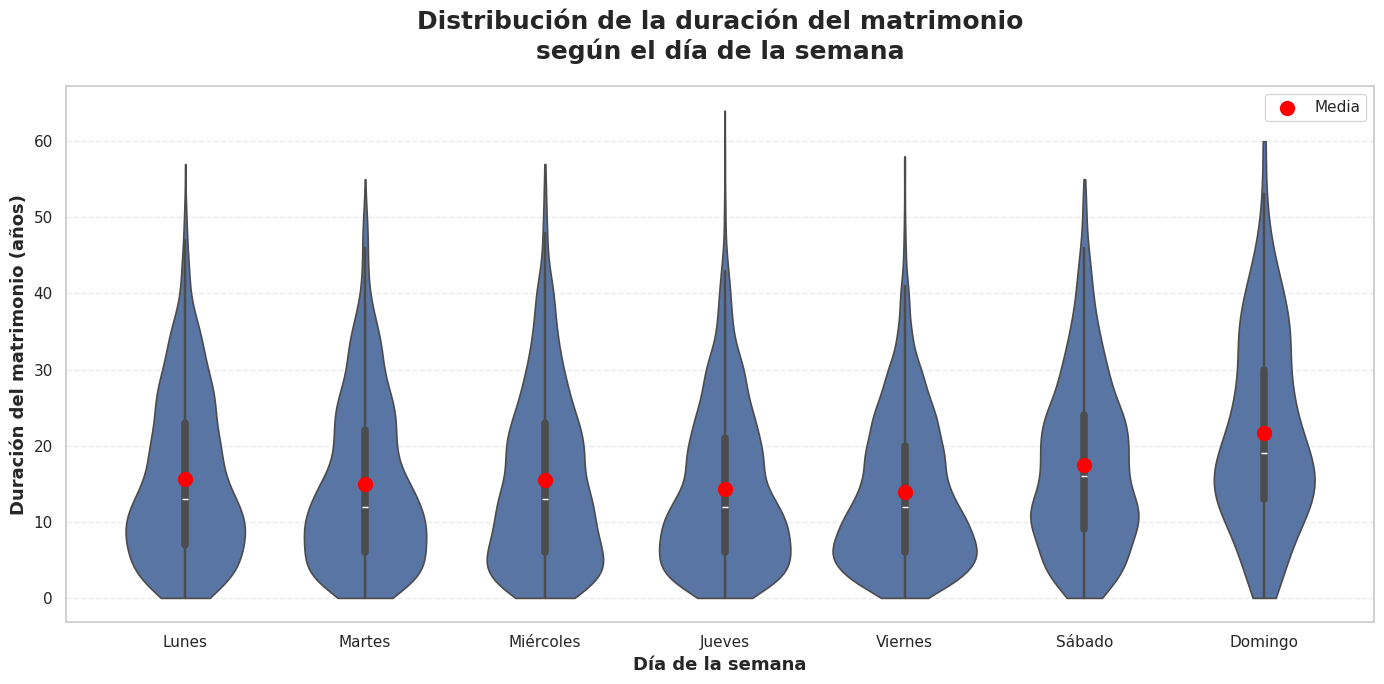

In [60]:
# ==========================================
# ESTILO GENERAL
# ==========================================
sns.set_theme(
    style='whitegrid',
    palette='deep'
)

# ==========================================
# CREAR FIGURA
# ==========================================
plt.figure(figsize=(14, 7))

# ==========================================
# VIOLINPLOT
# ==========================================
ax = sns.violinplot(
    data=df,
    x='dia_sem_mat',
    y='dur_mat',
    order=orden_dias,
    inner='box',     # mini boxplot interno
    cut=0,           # evita extender densidad fuera de datos reales
    linewidth=1.2
)

# ==========================================
# CALCULAR MEDIAS
# ==========================================
medias = (
    df.groupby('dia_sem_mat')['dur_mat']
      .mean()
      .reindex(orden_dias)
)

# ==========================================
# AGREGAR MEDIA EN ROJO
# ==========================================
ax.scatter(
    x=range(len(orden_dias)),
    y=medias,
    color='red',
    s=100,
    zorder=5,
    label='Media'
)

# ==========================================
# ETIQUETAS
# ==========================================
plt.xlabel(
    'Día de la semana',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Duración del matrimonio (años)',
    fontsize=13,
    fontweight='bold'
)

plt.title(
    'Distribución de la duración del matrimonio\nsegún el día de la semana',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# ==========================================
# GRID
# ==========================================
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# ==========================================
# TICKS
# ==========================================
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# ==========================================
# LEYENDA
# ==========================================
plt.legend(
    fontsize=11,
    frameon=True
)

# ==========================================
# AJUSTE FINAL
# ==========================================
plt.tight_layout()

plt.show()

*//El violinplot muestra que los matrimonios celebrados en domingo presentan una mayor duración central, tanto en media como en mediana, en comparación con los demás días de la semana. También se observa que la distribución de Domingo está más concentrada en valores altos de duración. Sin embargo, este resultado debe interpretarse con cautela, ya que Domingo tiene una cantidad de observaciones considerablemente menor que otros días, especialmente Viernes. Además, esta diferencia podría estar relacionada con factores temporales, como el año en que se celebró el matrimonio, y no necesariamente con el día de la semana en sí.*

*//Es temporal?*

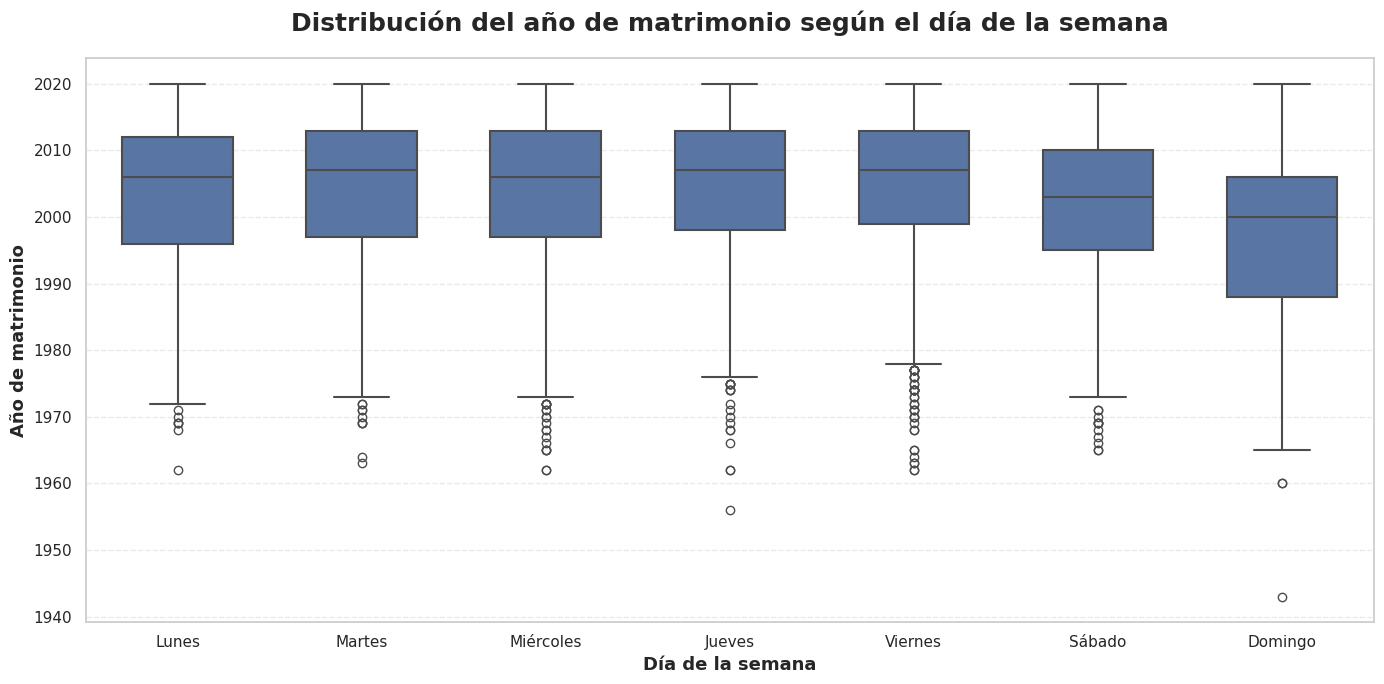

In [62]:

sns.set_theme(style='whitegrid', palette='deep')

plt.figure(figsize=(14, 7))

ax = sns.boxplot(
    data=df,
    x='dia_sem_mat',
    y='anio_mat',
    order=orden_dias,
    width=0.6,
    linewidth=1.5
)

plt.xlabel('Día de la semana', fontsize=13, fontweight='bold')
plt.ylabel('Año de matrimonio', fontsize=13, fontweight='bold')
plt.title(
    'Distribución del año de matrimonio según el día de la semana',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

*//No damos cuenta de que sí es temporal ya que días como Domingo o Jueves cuentan con outsiders muy pronunciados*

Q1: 6.0
Q3: 22.0
IQR: 16.0
Límite inferior: -18.0
Límite superior: 46.0
Datos originales: 12325
Datos después del filtro IQR: 12239


AttributeError: FillBetweenPolyCollection.set() got an unexpected keyword argument 'showfliers'

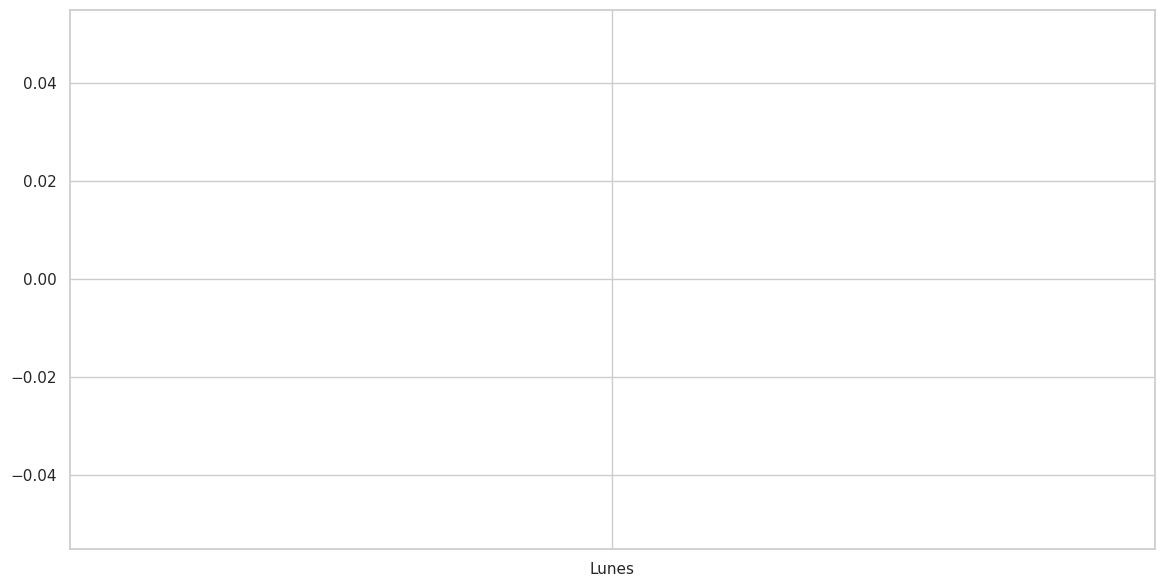

In [ ]:

# ==========================================
# CALCULAR Q1, Q3 E IQR DE dur_mat
# ==========================================
Q1 = df['dur_mat'].quantile(0.25)
Q3 = df['dur_mat'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

# ==========================================
# FILTRAR DATOS SIN OUTLIERS
# ==========================================
df_iqr = df[
    (df['dur_mat'] >= limite_inferior) &
    (df['dur_mat'] <= limite_superior)
].copy()

print("Datos originales:", len(df))
print("Datos después del filtro IQR:", len(df_iqr))

# ==========================================
# ESTILO
# ==========================================
sns.set_theme(style='whitegrid', palette='deep')

plt.figure(figsize=(14, 7))

# ==========================================
# BOXPLOT FILTRADO
# ==========================================
ax = sns.boxplot(
    data=df_iqr,
    x='dia_sem_mat',
    y='dur_mat',
    order=orden_dias,
    width=0.6,
    linewidth=1.5,
    showfliers=True,
    fliersize=3
)

# ==========================================
# MEDIA
# ==========================================
medias = (
    df_iqr.groupby('dia_sem_mat')['dur_mat']
          .mean()
          .reindex(orden_dias)
)

ax.scatter(
    x=range(len(orden_dias)),
    y=medias,
    color='red',
    s=100,
    zorder=5,
    label='Media'
)

# ==========================================
# ETIQUETAS
# ==========================================
plt.xlabel('Día de la semana', fontsize=13, fontweight='bold')
plt.ylabel('Duración del matrimonio (años)', fontsize=13, fontweight='bold')

plt.title(
    'Duración del matrimonio según el día de la semana\n'
    'filtrando valores extremos con el método IQR',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

*//Nos damos cuenta que perduran por que en domingo hay mas matrimonios viejitos.*

*//Creación de la variable:* **hijos_total: la suma de los hijos que quedan a tanto del divorciado 1 como del divorciado 2**

In [61]:
df['hijos_total'] = df[['hijos_1', 'hijos_2']].sum(axis=1)